# 03 · Connectivity — which connections are necessary?

*Task 03 of the rebuilt mRNN analysis. The base model is fixed by task 02; this asks what has to be
wired to what.*

**The baseline is the unconstrained model**: every region connected to every other, with
dense full-rank inter-regional blocks and no bottleneck. Each variant then removes
something and is **refitted from scratch**, so the question is always "can the data still
be reproduced without this?" rather than "how much does breaking a fitted model hurt?".

Those are different questions and the legacy analysis conflated them. Deleting a block
from an already-fitted network drove $R^2$ from 0.998 to about −2 for *every* block, which
says only that the readouts were tuned to the intact dynamics. Refitting asks the question
that has an interpretable answer.

| Arm | What it removes | Asks |
|---|---|---|
| baseline | nothing | how well can this be fitted at all |
| global structure | all cross-region blocks, or the dense within-region blocks | do regions need each other, and do they need internal recurrence |
| region isolation | every connection into and out of one region | can the other three be reproduced without it |
| directed removal | one directed pathway | is any single route load-bearing |
| bidirectional cut | both directions between one pair | do these two regions need to exchange |

Every arm is scored the same way: fit against the measured noise ceiling, the parameter
count that bought it, agreement across seeds, and a visual check of the traces.

| Section | |
|---|---|
| 1 | What task 01 settled, and the variants |
| 2 | Run state and submission (off by default) |
| 3 | Loss trajectories and convergence |
| 4 | Fit against the ceiling, and parameter cost |
| 5 | The visual check across the sweep |
| 6 | Seed agreement |
| 7 | Reading the result |

In [1]:
# The analysis code these notebooks call lives in src/ and is edited between runs. Without
# autoreload a kernel keeps whatever it imported first, so a function added to src after
# the kernel started raises AttributeError until it is restarted -- which is easy to
# misread as a bug in the code rather than in the kernel's cache.
%load_ext autoreload
%autoreload 2

from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import yaml
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_protocol as protocol
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_sweep as sweep
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_synthesis as syn
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_target_loss as tl
from dal_monte_2022_analysis.ephys.analysis import fixation_psth_noise_ceiling as ceiling_mod
from dal_monte_2022_analysis.ephys.plotting import fixation_mrnn_sweep as viz
from dal_monte_2022_analysis.ephys.plotting.thesis_common import (
    ThesisFigureSettings,
    apply_thesis_plot_style,
    figure_to_png_bytes,
    save_thesis_figure,
)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
MRNN_CFG_PATH = repo_root / "configs" / "ephys_fixation_mrnn.yaml"
apply_thesis_plot_style(load_config(repo_root / "configs" / "plotting.yaml"))

PROTOCOL_ROOT = protocol.resolve_chapter_root(DATASET_CFG_PATH, task="00_training_protocol")
CAPACITY_ROOT = sweep.resolve_task_root("01_capacity", DATASET_CFG_PATH)
TASK_ROOT = sweep.resolve_task_root("03_connectivity", DATASET_CFG_PATH)
CEILING_DIR = ceiling_mod.resolve_output_dir(DATASET_CFG_PATH)
FIGURE_DIR = syn.resolve_output_dir(DATASET_CFG_PATH, scope="03_connectivity")
FIGURES = ThesisFigureSettings(output_dir=FIGURE_DIR)

SELECTED_PROTOCOL, PROTOCOL_IS_PROVISIONAL = sweep.load_selected_protocol_or_provisional(
    PROTOCOL_ROOT / "selected_protocol.yaml"
)

#: Set True to queue this sweep before task 00 has frozen a recipe. Only the optimiser is
#: provisional in that case -- the architecture comes from the corrected
#: PROTOCOL_ARCHITECTURE either way -- and task 00's own confirmation grid is what would
#: overturn it. Worth doing when the cluster is the bottleneck; the run configs record
#: exactly what was used, so a mismatch stays detectable.
ALLOW_PROVISIONAL_PROTOCOL = False
REGIONS = tuple(SELECTED_PROTOCOL["architecture"].get("region_order", ("ofc", "bla", "dmpfc", "accg")))

#: Width comes from task 01. Until that sweep finishes the notebook falls back to 50 and
#: says so, so it can be read and reviewed before the dependency lands.
CAPACITY_PATH = CAPACITY_ROOT / "selected_capacity.yaml"
if CAPACITY_PATH.exists():
    SELECTED_CAPACITY = yaml.safe_load(CAPACITY_PATH.read_text())
    HIDDEN_UNITS = int(SELECTED_CAPACITY["hidden_units"])
    CAPACITY_SOURCE = f"task 01 (`{SELECTED_CAPACITY['selected_label']}`)"
else:
    SELECTED_CAPACITY = None
    HIDDEN_UNITS = 50
    CAPACITY_SOURCE = "**provisional fallback** — task 01 has not finished"

#: Set True to queue this sweep before task 01 has chosen a width. Cluster time is the
#: scarce resource and these arrays take hours, so waiting for a clean dependency can cost
#: more than the risk: if task 01 selects a different width, the runs fitted here are at
#: the wrong one and Section 1 will say so. The width every cell was actually trained at is
#: recorded in its own run_config.yaml either way, so a mismatch is always detectable.
ALLOW_PROVISIONAL_WIDTH = False

SWEEP_SEEDS = 3
GALLERY_REGION = "ofc"


def show(figure, stem: str) -> None:
    save_thesis_figure(figure, FIGURES, stem)
    display(Image(data=figure_to_png_bytes(figure, dpi=190)))


if PROTOCOL_IS_PROVISIONAL:
    print("recipe       : ** provisional: task 00 has not frozen one **")
print("regions      :", REGIONS)
if PROTOCOL_IS_PROVISIONAL:
    print("recipe       : ** provisional: task 00 has not frozen one **")
print("hidden units :", HIDDEN_UNITS)
print("task root    :", TASK_ROOT)

regions      : ('ofc', 'bla', 'dmpfc', 'accg')
hidden units : 40
task root    : /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/chapter/03_connectivity


## 1. The variants

All four arms share the width from task 01, the recipe from task 00, and dense
inter-regional blocks. Only the connectivity differs.

The **region isolation** arm removes every connection into *and* out of one region. That
region keeps its own within-region block, its condition input, its trained initial state
and its readout — it is still fitted, just autonomously — while the other three keep
talking to each other.

> **The loss is a sum over all four regions' readouts, so a single pooled score cannot
> read this arm.** Cutting a region off changes two things at once: the isolated region
> now has to reproduce its own trajectories without the others' input, *and* the remaining
> three have to reproduce theirs without its input. Those are different questions — a
> region can be perfectly reproducible alone while being indispensable to everyone else,
> or the reverse. Section 4a therefore reports the two costs **separately**, and only the
> second speaks to whether the region is necessary to the rest of the network.

The **pathway** arm comes in two forms, and the first is the reason for the second.

*Directed removal* takes out one block at a time — `a → b` while `b → a` stays. Measured on
the first pass, that is too weak a perturbation to read: every directed removal cost between
0.0001 and 0.0012 in ceiling-relative fit, against a baseline seed-to-seed spread of 0.0002.
Most were indistinguishable from noise. With twelve blocks between four regions, removing
one leaves eleven and the network simply reroutes.

*Bidirectional removal* severs a pair of regions from each other entirely — both `a → b`
and `b → a` — while each stays connected to the other two. Six unordered pairs. This sits
between the directed arm (2 of 12 blocks removed rather than 1) and region isolation (which
removes 6), and it is the granularity at which "these two regions need to talk to each
other" becomes a testable claim.

Both arms are kept. The directed one is what justifies the bidirectional one, and "single
directed pathways are individually dispensable" is a result in its own right.

In [2]:
from itertools import combinations

#: Directed removals, kept from the first pass: they establish that one-way cuts are too
#: weak to read, which is what motivates the bidirectional arm.
PATHWAYS_TO_TEST = [(source, "bla") for source in REGIONS if source != "bla"] + \
                   [("bla", target) for target in REGIONS if target != "bla"]
#: Every unordered pair, severed in both directions. Six of them for four regions.
PAIRS_TO_CUT = list(combinations(REGIONS, 2))

# l1_weight_scale is set to 0 rather than inherited. The task-00 recipe carries 0.01,
# which came from the legacy ensembles and was never chosen -- and at that value it is not
# a sparsity prior but an ablation: in the fitted h40 model it drives the within-region
# blocks to ~1e-6 against ~1e-1 for the cross-region blocks, five orders of magnitude
# down. That would make `within_region_only` below a model with almost no recurrence at
# all, and would make `full` and `cross_plus_self_diagonal` near-duplicates. Sparsity is
# swept properly in task 04.
base_overrides = {"hidden_units": HIDDEN_UNITS, "recurrent_bottleneck_dim": None,
                  "l1_weight_scale": 0.0}

variants = [
    sweep.ModelVariant(label="full", arm="baseline",
                       overrides={**base_overrides, "recurrent_connectivity": "full"}),
    sweep.ModelVariant(label="within_region_only", arm="global structure",
                       overrides={**base_overrides, "recurrent_connectivity": "within_region"}),
    sweep.ModelVariant(label="cross_plus_self_diagonal", arm="global structure",
                       overrides={**base_overrides,
                                  "recurrent_connectivity": "cross_region_with_self_diagonal"}),
]
for region in REGIONS:
    blocked = tuple(
        [(region, other) for other in REGIONS if other != region]
        + [(other, region) for other in REGIONS if other != region]
    )
    variants.append(sweep.ModelVariant(
        label=f"isolate_{region}", arm="region isolation",
        overrides={**base_overrides, "recurrent_connectivity": "full",
                   "recurrent_blocked_pairs": blocked},
    ))
for source, target in PATHWAYS_TO_TEST:
    variants.append(sweep.ModelVariant(
        label=f"drop_{source}_to_{target}", arm="directed removal",
        overrides={**base_overrides, "recurrent_connectivity": "full",
                   "recurrent_blocked_pairs": ((source, target),)},
    ))
for first, second in PAIRS_TO_CUT:
    variants.append(sweep.ModelVariant(
        label=f"cut_{first}_{second}", arm="bidirectional cut",
        overrides={**base_overrides, "recurrent_connectivity": "full",
                   "recurrent_blocked_pairs": ((first, second), (second, first))},
    ))

seeds = protocol.protocol_seeds(n_seeds=SWEEP_SEEDS)
BASELINE = "full"

display(Markdown(f"Width **{HIDDEN_UNITS}** units per region, from {CAPACITY_SOURCE}."))

# What the *trained* runs were fitted at, which may predate task 01's answer. Only runs
# with a checkpoint count: generating the job commands writes a run_config.yaml for every
# cell whether or not it is ever submitted, so staged configs are not evidence of anything.
_trained = sorted(
    path for path in TASK_ROOT.glob("*/seed=*/run_config.yaml")
    if (path.parent / "checkpoint_best.pth").exists()
)
if _trained:
    _widths = {int(yaml.safe_load(path.read_text())["hidden_units"]) for path in _trained}
    if _widths != {HIDDEN_UNITS}:
        display(Markdown(
            f"🔴 **Width mismatch.** {len(_trained)} trained run(s) used {sorted(_widths)} units, "
            f"but the current selection is {HIDDEN_UNITS}. Those runs answer the question at the "
            f"wrong width and should be refitted before the results below are used."
        ))
    else:
        display(Markdown(f"{len(_trained)} trained run(s), all at {HIDDEN_UNITS} units."))
display(pd.DataFrame([{"label": v.label, "arm": v.arm,
                       "connectivity": v.overrides.get("recurrent_connectivity"),
                       "blocked pairs": len(v.overrides.get("recurrent_blocked_pairs", ()))}
                      for v in variants]))
display(Markdown(
    f"**{len(variants)} variants × {len(seeds)} seeds = {len(variants) * len(seeds)} runs** at "
    f"{SELECTED_PROTOCOL['epochs']:,} iterations."
))

Width **40** units per region, from task 01 (`h40`).

39 trained run(s), all at 40 units.

,label,arm,connectivity,blocked pairs
0,full,baseline,full,0
1,within_region_only,global structure,within_region,0
2,cross_plus_self_diagonal,global structure,cross_region_with_self_diagonal,0
3,isolate_ofc,region isolation,full,6
4,isolate_bla,region isolation,full,6
5,isolate_dmpfc,region isolation,full,6
6,isolate_accg,region isolation,full,6
7,drop_ofc_to_bla,directed removal,full,1
8,drop_dmpfc_to_bla,directed removal,full,1
9,drop_accg_to_bla,directed removal,full,1


**19 variants × 3 seeds = 57 runs** at 100,000 iterations.

## 2. Run state and submission

Submission happens **only** if you set `SUBMIT = True`, and is blocked while a previously
submitted array is still on the queue.

In [3]:
SUBMIT = False   # <-- set to True to actually submit the missing cells

commands, run_dirs = sweep.variant_job_commands(
    variants, seeds, root=TASK_ROOT, repo_root=repo_root,
    protocol=SELECTED_PROTOCOL, mrnn_cfg_path=MRNN_CFG_PATH,
)
inventory = sweep.index_variant_runs(TASK_ROOT, variants, seeds)
job_state = protocol.running_job_state(TASK_ROOT / "_jobs")

if PROTOCOL_IS_PROVISIONAL:
    display(Markdown(
        "⚠️ **Task 00 has not frozen a recipe**, so the optimiser here is the provisional one "
        "(`lr 1e-3`, cosine, clip 0.05). The architecture is not provisional. "
        + ("`ALLOW_PROVISIONAL_PROTOCOL` is set, so submission is allowed."
           if ALLOW_PROVISIONAL_PROTOCOL else
           "Submission is blocked; set `ALLOW_PROVISIONAL_PROTOCOL = True` to queue anyway.")
    ))

if SELECTED_CAPACITY is None:
    display(Markdown(
        f"⚠️ **Task 01 has not finished**, so these cells would be fitted at the provisional "
        f"width of **{HIDDEN_UNITS}** units. "
        + ("`ALLOW_PROVISIONAL_WIDTH` is set, so submission is allowed — Section 1 will flag a "
           "mismatch once task 01 reports."
           if ALLOW_PROVISIONAL_WIDTH else
           "Submission is blocked; set `ALLOW_PROVISIONAL_WIDTH = True` to queue anyway.")
    ))
display(Markdown(
    f"**{int(inventory['complete'].sum())} complete**, **{int(inventory['diverged'].sum())} diverged**, "
    f"**{int(inventory['pending'].sum())} not yet run** of {len(inventory)} cells."
))
if job_state["active"]:
    display(Markdown(
        f"⚠️ **Job array `{job_state['job_id']}` is still on the queue** "
        f"({', '.join(f'{n} {s.lower()}' for s, n in sorted(job_state['states'].items()))})."
    ))
elif commands:
    display(Markdown(f"{len(commands)} run(s) would be submitted."))
    print("first command:\n")
    print(commands[0])

**39 complete**, **0 diverged**, **18 not yet run** of 57 cells.

18 run(s) would be submitted.

first command:

cd /gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis && FIXATION_MRNN_PROGRESS=off conda run -n gaze_processing python scripts/ephys/modeling/train_fixation_mrnn_into_run_dir.py --mrnn-cfg /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/chapter/03_connectivity/cut_ofc_bla/seed=271795885/run_config.yaml --run-dir /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/chapter/03_connectivity/cut_ofc_bla/seed=271795885 --seed 271795885 --device auto --overwrite


In [4]:
if job_state["active"]:
    display(Markdown(f"Nothing submitted: job array `{job_state['job_id']}` is still running."))
elif SUBMIT and commands and SELECTED_CAPACITY is None and not ALLOW_PROVISIONAL_WIDTH:
    display(Markdown(
        f"**Not submitted**: task 01 has not selected a width, so these cells would be fitted at "
        f"the provisional {HIDDEN_UNITS} units. Set `ALLOW_PROVISIONAL_WIDTH = True` to queue them "
        f"anyway — worth doing when the cluster is the bottleneck, since a mismatch is detectable "
        f"afterwards and only costs a refit."
    ))
elif SUBMIT and commands and PROTOCOL_IS_PROVISIONAL and not ALLOW_PROVISIONAL_PROTOCOL:
    display(Markdown(
        "**Not submitted**: task 00 has not frozen a recipe. Set "
        "`ALLOW_PROVISIONAL_PROTOCOL = True` to queue on the provisional optimiser."
    ))
elif SUBMIT and commands:
    from dal_monte_2022_analysis.runtime.hpc.jobs import submit_dsq_array_job, write_job_file

    jobs_dir = TASK_ROOT / "_jobs"
    jobs_dir.mkdir(parents=True, exist_ok=True)
    job_file = jobs_dir / "connectivity.txt"
    write_job_file(job_file, commands)
    job_id = submit_dsq_array_job(
        job_file_path=job_file, sbatch_script_path=jobs_dir / "connectivity.sh",
        log_dir=jobs_dir / "logs", job_name="mrnn_connectivity", partition="psych_gpu",
        cpus_per_task=1, mem_per_cpu="12G", time_limit="06:00:00", gres="gpu:1",
    )
    (jobs_dir / "job_id.txt").write_text(str(job_id) + "\n")
    display(Markdown(f"Submitted **{len(commands)}** runs as job array **{job_id}**."))
elif commands:
    display(Markdown("`SUBMIT` is **False** — nothing was submitted."))
else:
    display(Markdown("Every cell is already trained; go on to Section 3."))

`SUBMIT` is **False** — nothing was submitted.

## 3. Loss trajectories and convergence

A constraint that merely makes optimisation harder looks the same in the final loss as
one the data cannot tolerate. Only the trajectory separates them, so this comes first.

,label,n_seeds,n_converged,worst_late_spikes,worst_final_over_best,median_best_loss,best_loss_spread
0,full,3,3,0,1.00001,0.00018,1.03099
1,within_region_only,3,3,0,1.00000,0.00048,1.04162
2,cross_plus_self_diagonal,3,3,0,1.00000,0.00022,1.03747
3,isolate_ofc,3,2,1,1.00000,0.00031,1.04411
4,isolate_bla,3,3,0,1.00014,0.00034,1.18747
5,isolate_dmpfc,3,3,0,1.00001,0.00027,1.04577
6,isolate_accg,3,3,0,1.00002,0.00027,1.02872
7,drop_ofc_to_bla,3,3,0,1.00003,0.00019,1.01771
8,drop_dmpfc_to_bla,3,2,1,1.00003,0.00019,1.07551
9,drop_accg_to_bla,3,3,0,1.00000,0.00019,1.04486


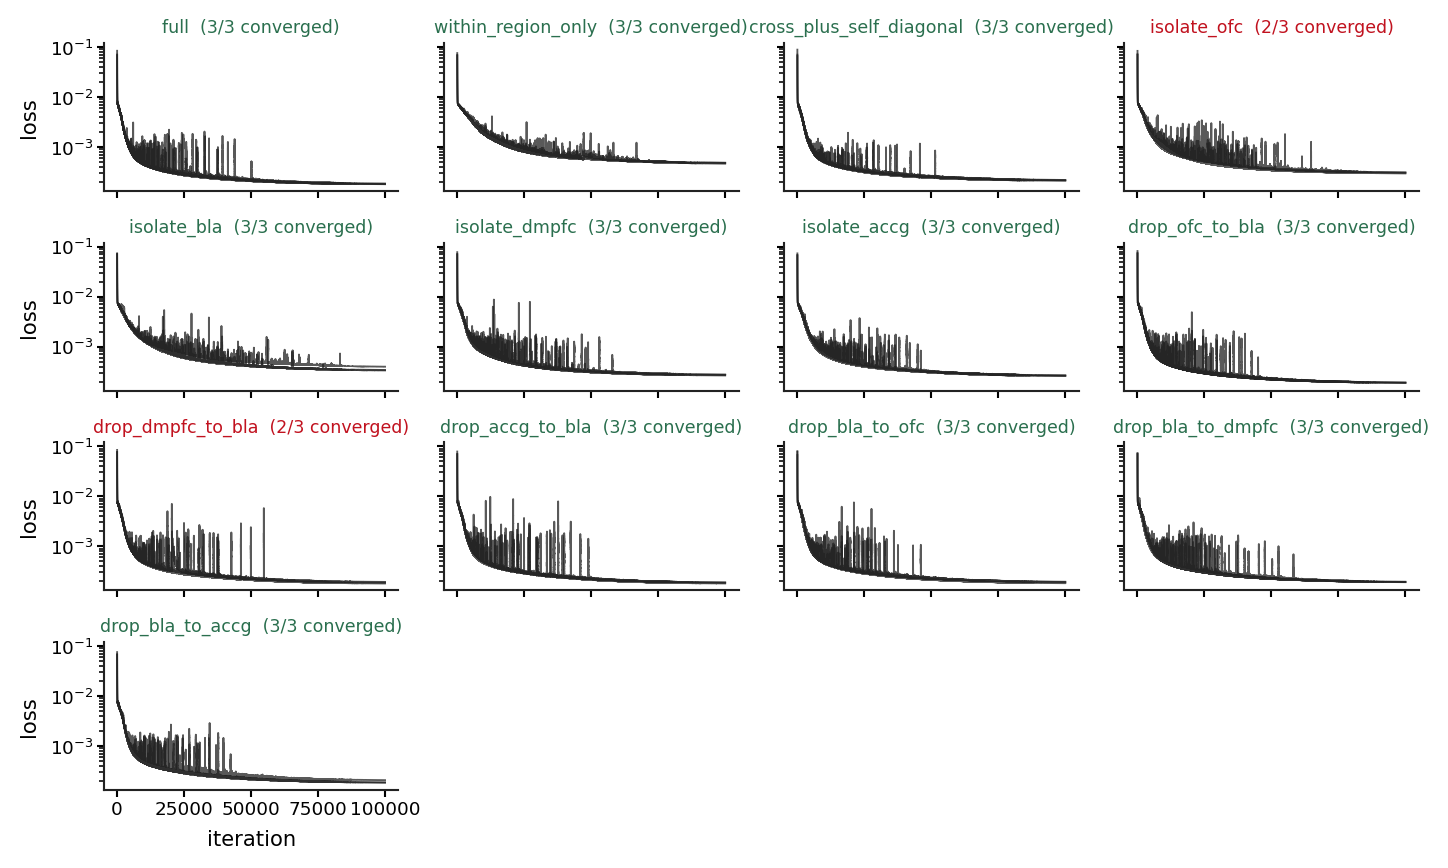

In [5]:
histories = sweep.load_histories(inventory)
labels = [v.label for v in variants if v.label in histories]

if not histories:
    display(Markdown("No completed runs yet — this section fills in as the sweep lands."))
else:
    convergence = sweep.convergence_table(histories)
    display(convergence.round(5))
    show(viz.plot_sweep_loss_trajectories(histories, convergence=convergence, n_columns=4),
         "fig01_loss_trajectories")

### 3a. Constraints that need a smaller step

The recipe is selected on the **unconstrained** model, and the optimum is
architecture-dependent — on this problem the best learning rate moved by a factor of three
when the rank constraint and the within-region penalty were removed. So a constrained
variant that fails the bar has two possible explanations, and they mean opposite things:

- the data cannot be reproduced under that constraint — the result this sweep is for;
- the inherited recipe cannot *optimise* it — a statement about the optimiser, not the brain.

Scoring a failure without separating them would report the second as the first. Any variant
that fails is therefore refitted at successively lower learning rates, and which rate each
one needed is reported rather than hidden: "this constraint required a smaller step" is
itself informative about the loss landscape it induces.

In [6]:
if histories:
    retries = sweep.retry_variants_for_nonconverged(
        variants, convergence, inherited_lr=float(SELECTED_PROTOCOL["optimizer"]["lr"])
    )
    if not retries:
        display(Markdown("Every variant converged at the inherited learning rate; no retries needed."))
    else:
        retry_commands, _ = sweep.variant_job_commands(
            retries, seeds, root=TASK_ROOT, repo_root=repo_root,
            protocol=SELECTED_PROTOCOL, mrnn_cfg_path=MRNN_CFG_PATH,
        )
        retry_inventory = sweep.index_variant_runs(TASK_ROOT, retries, seeds)
        display(Markdown(
            f"**{len(set(r.label.split('__')[0] for r in retries))} variant(s) failed the bar**, "
            f"giving {len(retries)} retry configurations "
            f"({int(retry_inventory['complete'].sum())} already trained, {len(retry_commands)} to run). "
            f"Submit them the same way as Section 2, then re-run this notebook."
        ))
        if retry_commands and SUBMIT and not job_state["active"]:
            from dal_monte_2022_analysis.runtime.hpc.jobs import submit_dsq_array_job, write_job_file

            jobs_dir = TASK_ROOT / "_jobs_retry"
            jobs_dir.mkdir(parents=True, exist_ok=True)
            job_file = jobs_dir / "retry.txt"
            write_job_file(job_file, retry_commands)
            retry_id = submit_dsq_array_job(
                job_file_path=job_file, sbatch_script_path=jobs_dir / "retry.sh",
                log_dir=jobs_dir / "logs", job_name="mrnn_retry", partition="psych_gpu",
                cpus_per_task=1, mem_per_cpu="12G", time_limit="06:00:00", gres="gpu:1",
            )
            (jobs_dir / "job_id.txt").write_text(str(retry_id) + "\n")
            display(Markdown(f"Submitted **{len(retry_commands)}** retries as job array **{retry_id}**."))

        retry_histories = sweep.load_histories(retry_inventory)
        if retry_histories:
            combined = pd.concat([convergence, sweep.convergence_table(retry_histories)], ignore_index=True)
            resolved = sweep.resolve_best_converged(combined, base_labels=[v.label for v in variants])
            display(resolved.round(6))
            inventory = pd.concat([inventory, retry_inventory], ignore_index=True)
            histories = {**histories, **retry_histories}
            labels = list(resolved.loc[resolved["converged"], "used_label"])

**2 variant(s) failed the bar**, giving 4 retry configurations (0 already trained, 12 to run). Submit them the same way as Section 2, then re-run this notebook.

## 4. Fit, and what it cost

Scored against the measured noise ceiling. The parameter count matters more here than in
task 01: every constraint in this sweep also *removes* parameters, so a variant that fits
as well as the baseline with fewer of them is the interesting outcome, and one that fits
worse has to be checked against how much smaller it is before that is called a structural
result.

,mean,min,arm,inter_region,total,parameters_per_datum,cost_vs_baseline
label,,,,,,,
drop_accg_to_bla,1.0096,0.9701,directed removal,17600,31848,0.6319,-0.0003
full,1.0093,0.9649,baseline,19200,33448,0.6637,0.0000
drop_dmpfc_to_bla,1.0092,0.9664,directed removal,17600,31848,0.6319,0.0001
drop_ofc_to_bla,1.0086,0.9623,directed removal,17600,31848,0.6319,0.0007
drop_bla_to_ofc,1.0084,0.9655,directed removal,17600,31848,0.6319,0.0009
drop_bla_to_dmpfc,1.0082,0.9583,directed removal,17600,31848,0.6319,0.0011
drop_bla_to_accg,1.0081,0.9592,directed removal,17600,31848,0.6319,0.0012
cross_plus_self_diagonal,1.0061,0.9584,global structure,19200,27208,0.5398,0.0032
isolate_bla,1.0021,0.9412,region isolation,9600,23848,0.4732,0.0072


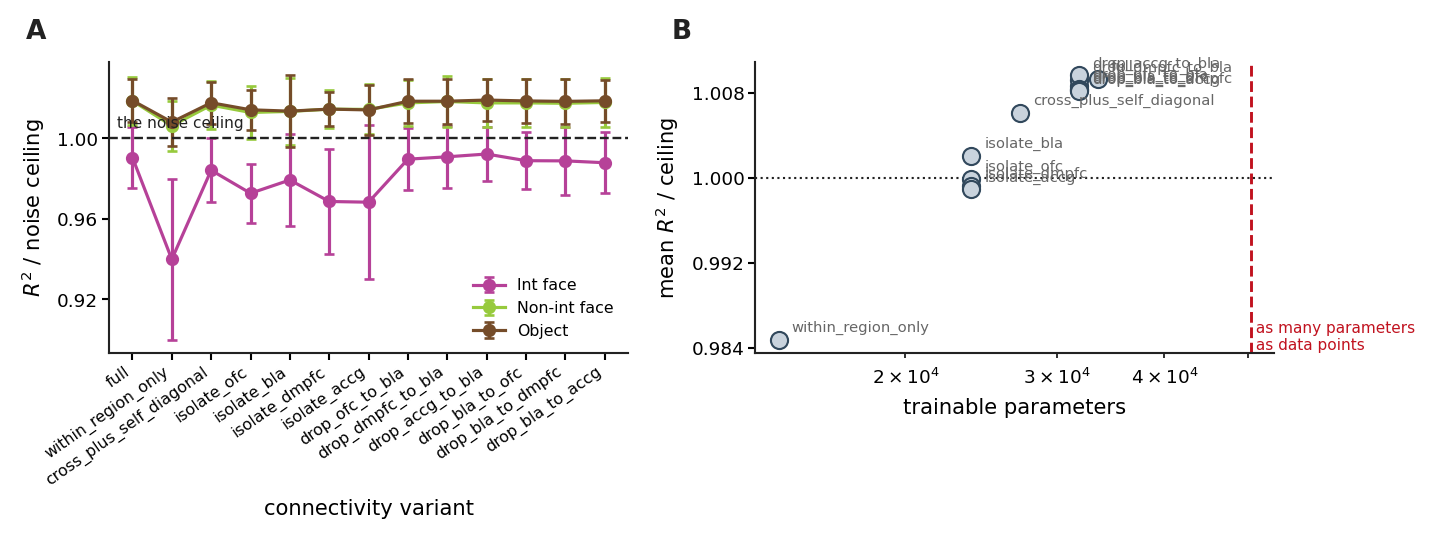

In [7]:
pc_ceiling = pd.read_csv(CEILING_DIR / "pc_space_ceiling.csv")
ceiling_by_region = pc_ceiling.groupby("region")["reliability"].mean().to_dict()

if not histories:
    display(Markdown("Nothing to score yet."))
else:
    fit = sweep.score_variant_fit(inventory, ceiling_by_region)
    parameters = pd.DataFrame([
        {"label": label, "arm": inventory[inventory["label"] == label]["arm"].iloc[0],
         **sweep.count_trainable_parameters(
             inventory[(inventory["label"] == label) & inventory["complete"]].iloc[0]["run_dir"])}
        for label in labels
    ])
    summary = (
        fit.groupby("label")["r2_vs_ceiling"].agg(["mean", "min"])
        .join(parameters.set_index("label")[["arm", "inter_region", "total", "parameters_per_datum"]])
        .loc[labels]
    )
    reference = float(summary.loc[BASELINE, "mean"]) if BASELINE in summary.index else np.nan
    summary["cost_vs_baseline"] = reference - summary["mean"]
    display(summary.sort_values("cost_vs_baseline").round(4))
    show(viz.plot_fit_versus_constraint(fit, parameters, order=labels,
                                        x_label="connectivity variant"), "fig02_fit_vs_connectivity")

In [8]:
if histories:
    by_condition = (
        fit.groupby(["label", "condition"])["r2_vs_ceiling"].mean().unstack().loc[labels]
    )
    display(Markdown(
        "Broken down by condition. The legacy single-seed comparison found the cost of removing "
        "inter-regional coupling several times larger for interactive-face fixations than for the "
        "others; whether that survives refitting across seeds is the question this table answers."
    ))
    display(by_condition.round(4))

Broken down by condition. The legacy single-seed comparison found the cost of removing inter-regional coupling several times larger for interactive-face fixations than for the others; whether that survives refitting across seeds is the question this table answers.

condition,face_interactive,face_non_interactive,object
label,,,
full,0.9905,1.0186,1.0188
within_region_only,0.9399,1.0063,1.0081
cross_plus_self_diagonal,0.9841,1.0165,1.0177
isolate_ofc,0.9727,1.0129,1.0142
isolate_bla,0.9793,1.0134,1.0135
isolate_dmpfc,0.9686,1.0145,1.0145
isolate_accg,0.9682,1.0144,1.0141
drop_ofc_to_bla,0.9896,1.0176,1.0185
drop_dmpfc_to_bla,0.9908,1.0183,1.0185


### 4a. Region isolation, decomposed

Each isolation is two experiments in one, and the pooled score above mixes them. Split
apart:

- **isolated_cost** — how much worse the cut-off region's *own* trajectories are once it
  has only its condition input and its internal recurrence. A large cost means that region
  depends on the others.
- **remaining_cost** — how much worse the *other three* are without it. A large cost means
  that region is necessary to them.

The second column is the one that speaks to network structure. A region can score badly on
the first and not at all on the second — that would say it is driven by the network rather
than driving it.

In [9]:
if histories:
    isolated_by_label = {
        v.label: v.label.replace("isolate_", "")
        for v in variants if v.arm == "region isolation" and v.label in labels
    }
    if isolated_by_label and BASELINE in labels:
        isolation = sweep.decompose_isolation_fit(
            fit, isolated_region_by_label=isolated_by_label, baseline_label=BASELINE
        )
        display(isolation.round(4))
        worst_self = isolation.loc[isolation["isolated_cost"].idxmax()]
        worst_others = isolation.loc[isolation["remaining_cost"].idxmax()]
        display(Markdown(
            f"The region that suffers most from being cut off is **{worst_self['isolated_region']}** "
            f"(its own fit falls {float(worst_self['isolated_cost']):.4f}), and the region the others "
            f"miss most is **{worst_others['isolated_region']}** (their fit falls "
            f"{float(worst_others['remaining_cost']):.4f}). Where those are different regions, the "
            f"network is asymmetric: one region is a listener and another a driver."
        ))
    else:
        display(Markdown("Needs the baseline and at least one isolation variant."))

,label,isolated_region,isolated_fit,isolated_baseline,isolated_cost,remaining_fit,remaining_baseline,remaining_cost
0,isolate_ofc,ofc,0.9929,1.0167,0.0238,1.0023,1.0068,0.0046
1,isolate_bla,bla,0.9789,0.9997,0.0207,1.0098,1.0125,0.0027
2,isolate_dmpfc,dmpfc,0.9952,1.0237,0.0285,1.0005,1.0045,0.0040
3,isolate_accg,accg,0.9700,0.9972,0.0272,1.0086,1.0133,0.0048


The region that suffers most from being cut off is **dmpfc** (its own fit falls 0.0285), and the region the others miss most is **accg** (their fit falls 0.0048). Where those are different regions, the network is asymmetric: one region is a listener and another a driver.

## 5. The visual check

One row per variant, all showing the same three components of the same region. A
constraint can leave $R^2$ almost untouched and still visibly change the shape of the
trajectory, which is exactly what happened to interactive face in task 00.

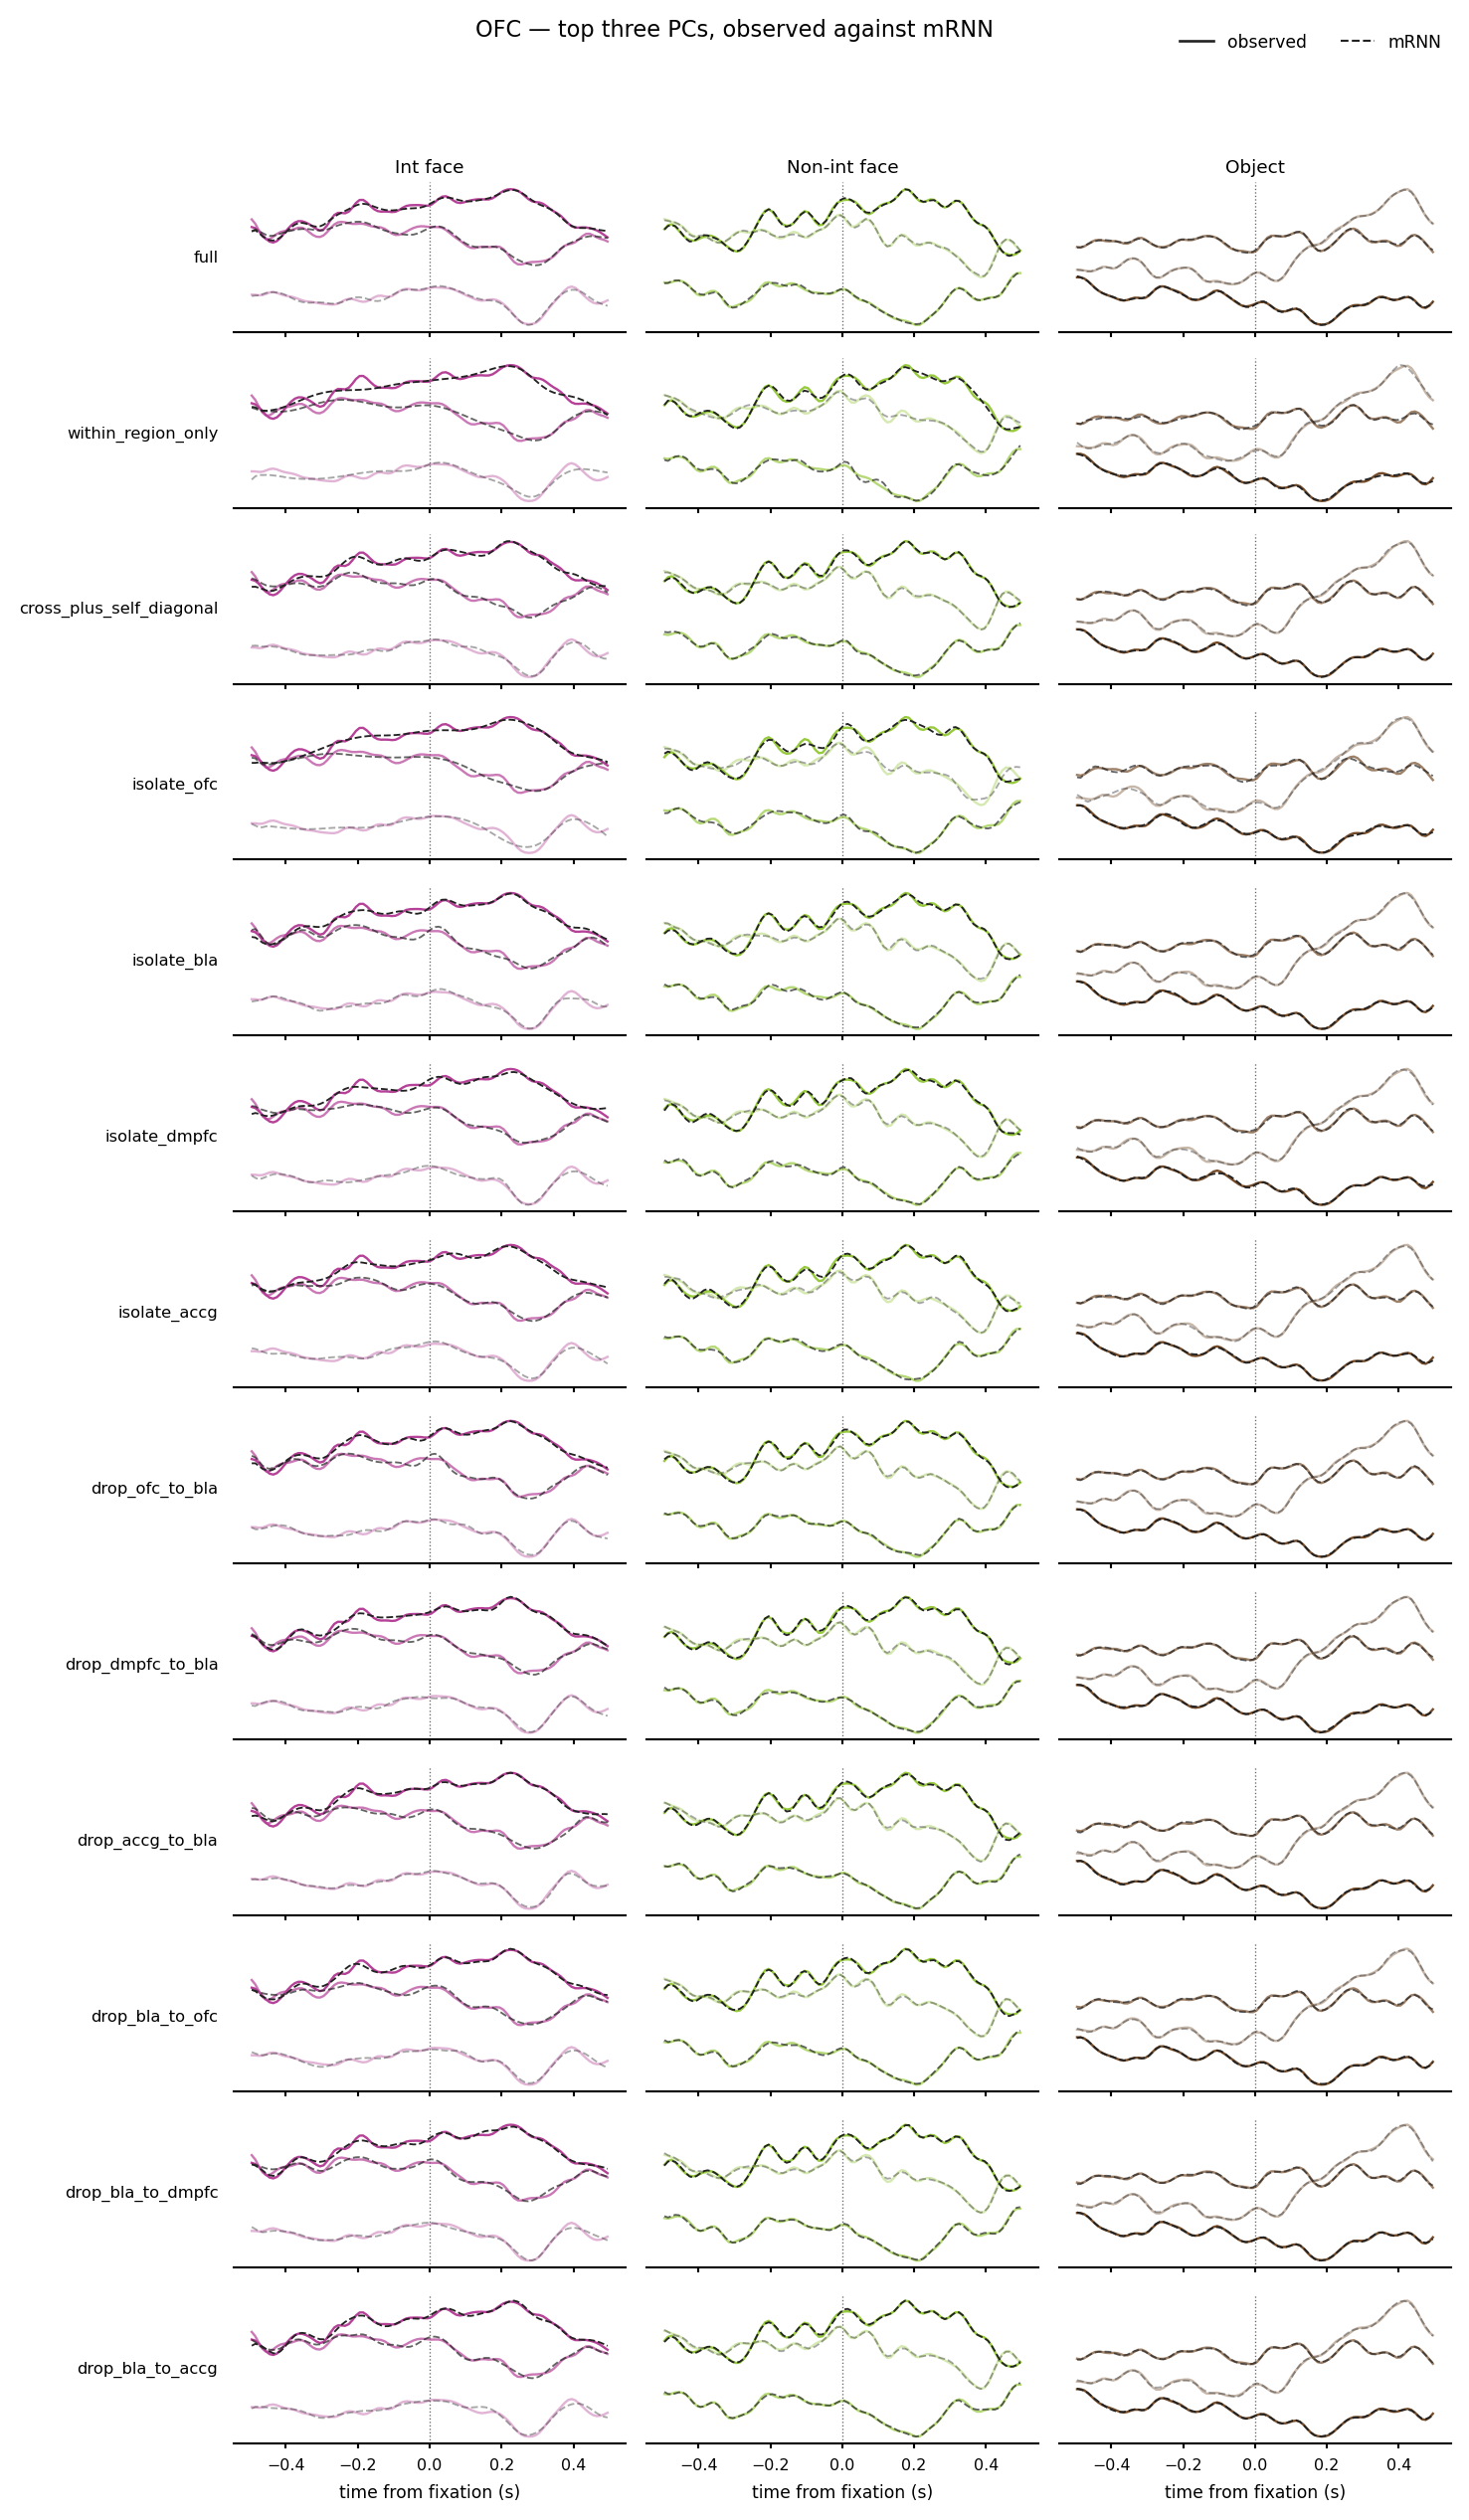

In [10]:
if histories:
    pc_traces = sweep.gallery_traces(inventory, region=GALLERY_REGION, space="pc", indices=(0, 1, 2))
    show(viz.plot_fit_gallery(pc_traces, order=labels,
                              title=f"{GALLERY_REGION.upper()} — top three PCs, observed against mRNN"),
         "fig03_gallery_pc")

## 6. Seed agreement

The axis on which a constrained model can beat the unconstrained one. Removing
connections removes ways of producing the same output, so if any structural constraint
makes the solution more identifiable, it should show here — and identifiability is what
every downstream circuit claim needs.

feature,inter-regional current magnitude,latent drive geometry,output trajectories
label,,,
full,0.6249,0.6584,0.9960
within_region_only,0.9749,0.4647,0.9901
cross_plus_self_diagonal,0.9068,0.6330,0.9955
isolate_ofc,0.9702,0.5559,0.9937
isolate_bla,0.9714,0.6228,0.9913
isolate_dmpfc,0.9679,0.5793,0.9942
isolate_accg,0.9509,0.5172,0.9940
drop_ofc_to_bla,0.8388,0.6603,0.9961
drop_dmpfc_to_bla,0.8263,0.6676,0.9961


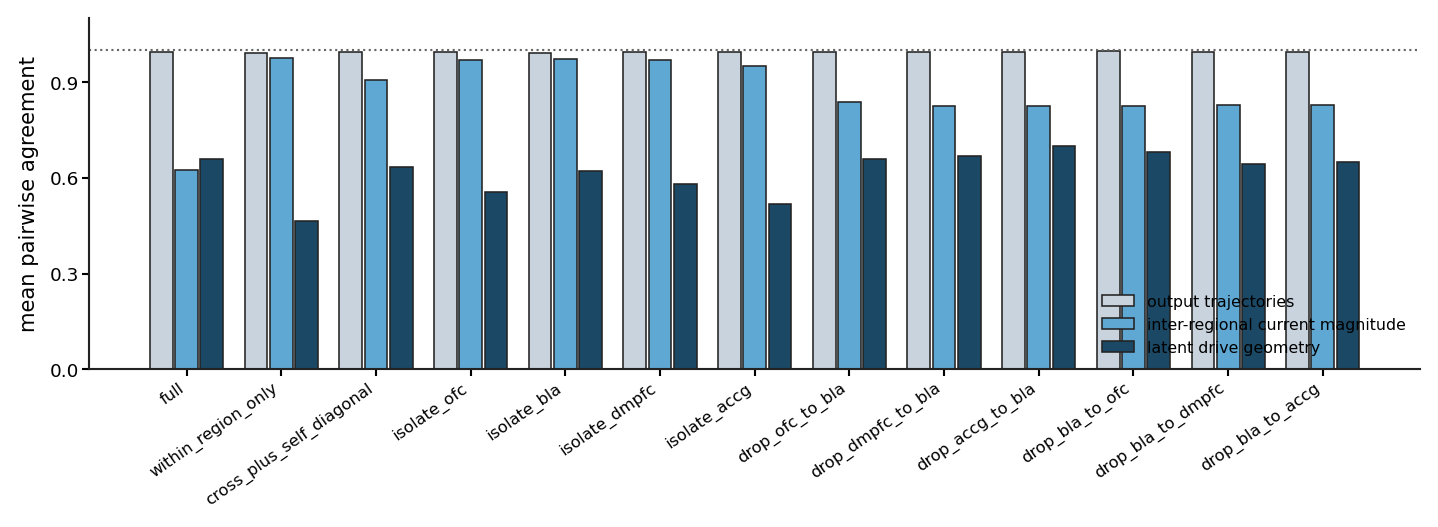

In [11]:
if histories:
    agreement = pd.concat([
        tl.inter_seed_agreement(list(block["run_dir"])).assign(label=label)
        for label, block in inventory[inventory["complete"].astype(bool)].groupby("label", sort=False)
    ], ignore_index=True)
    display(agreement.pivot_table(index="label", columns="feature", values="mean_agreement")
            .loc[labels].round(4))
    show(viz.plot_seed_agreement_by_variant(agreement, order=labels), "fig04_seed_agreement")

## 7. Reading the result

Nothing is "selected" here — connectivity is the object of study, not a hyperparameter.
What the sweep produces is a statement about which constraints the data tolerates, and it
is written to `connectivity_findings.csv` for the chapter.

The three readings to make, in order:

1. **Which removals are free?** A variant within the seed-to-seed spread of the baseline
   removes connections the data does not need. Those are the strongest claims available
   here, because they survive refitting. For the isolation arm, read the decomposed costs
   in Section 4a rather than the pooled score — a region whose removal looks expensive may
   simply be hard to reproduce alone.

   Read the arms as a ladder of severity: one directed block, then a pair severed both
   ways, then a region cut off entirely. A cost that appears only at the second rung says
   the two regions need a bidirectional exchange rather than a one-way input.
2. **Which removals cost, and does the cost concentrate in one condition?** A structural
   requirement that appears only during interactive-face fixations would be the
   substantive result.
3. **Does any constraint raise seed agreement?** If a smaller model is more identifiable
   at no cost in fit, that is the model tasks 05–07 should be built on.

In [12]:
if not histories:
    display(Markdown("Deferred until the sweep completes."))
else:
    spread = float(fit[fit["label"] == BASELINE].groupby("seed")["r2_vs_ceiling"].mean().std())
    geometry = agreement[agreement["feature"] == "latent drive geometry"].set_index("label")["mean_agreement"]
    findings = summary.join(geometry.rename("seed_agreement_geometry"))
    findings["free_removal"] = findings["cost_vs_baseline"] <= 2 * spread
    findings["more_identifiable"] = (
        findings["seed_agreement_geometry"] > float(geometry.get(BASELINE, np.nan))
    )
    findings.to_csv(TASK_ROOT / "connectivity_findings.csv")
    display(findings.round(4))
    free = [str(i) for i in findings.index[findings["free_removal"]] if str(i) != BASELINE]
    display(Markdown(
        f"Baseline seed-to-seed spread in ceiling-relative fit is **{spread:.4f}**, so a removal is "
        f"called free when it costs less than twice that.\n\n"
        f"**Free removals:** {', '.join(free) if free else 'none'}.\n\n"
        f"Written to `{TASK_ROOT / 'connectivity_findings.csv'}`."
    ))

,mean,min,arm,inter_region,total,parameters_per_datum,cost_vs_baseline,seed_agreement_geometry,free_removal,more_identifiable
label,,,,,,,,,,
full,1.0093,0.9649,baseline,19200,33448,0.6637,0.0000,0.6584,True,False
within_region_only,0.9847,0.8432,global structure,0,14248,0.2827,0.0246,0.4647,False,False
cross_plus_self_diagonal,1.0061,0.9584,global structure,19200,27208,0.5398,0.0032,0.6330,False,False
isolate_ofc,0.9999,0.9511,region isolation,9600,23848,0.4732,0.0094,0.5559,False,False
isolate_bla,1.0021,0.9412,region isolation,9600,23848,0.4732,0.0072,0.6228,False,False
isolate_dmpfc,0.9992,0.9269,region isolation,9600,23848,0.4732,0.0101,0.5793,False,False
isolate_accg,0.9989,0.8908,region isolation,9600,23848,0.4732,0.0104,0.5172,False,False
drop_ofc_to_bla,1.0086,0.9623,directed removal,17600,31848,0.6319,0.0007,0.6603,False,True
drop_dmpfc_to_bla,1.0092,0.9664,directed removal,17600,31848,0.6319,0.0001,0.6676,True,True


Baseline seed-to-seed spread in ceiling-relative fit is **0.0002**, so a removal is called free when it costs less than twice that.

**Free removals:** drop_dmpfc_to_bla, drop_accg_to_bla.

Written to `/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/chapter/03_connectivity/connectivity_findings.csv`.

## 8. What comes next

**Next:** `04_bottleneck_rank.ipynb`. This task establishes *which* inter-regional blocks
have to exist; task 03 asks how much has to pass through the ones that do, by constraining
each surviving block to rank $r$ and measuring against the dense baseline fitted here.

The two together are the structural claim the chapter rests on, and both are stated as
"the data still supports this under constraint X" rather than as a model ranking.